In [1]:
#загружаю библиотеки
!pip install matplotlib seaborn scipy lightgbm catboost -q
!pip install --upgrade matplotlib seaborn scikit-learn -q
!pip install phik -q

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import phik
import seaborn as sns
import scipy.stats as st
import random
import time
import lightgbm as lgbm

from matplotlib import pyplot as plt
from phik import resources, report
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import train_test_split, RandomizedSearchCV, HalvingGridSearchCV, cross_validate, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

**Цель исследования:** 

Построить модель машинного обучения, которая поможет определить рыночную стоимость автомобиля. 

**Ход исследования:**

1. Подготовка данных: загрузка и изучение общей информации из датасетов, обработка дубликатов и изменение типов данных, исследовательский анализ данных
2. Обучение моделей
3. Анализ моделей: время обучения, время предсказания и качество моделей, выбор лучшей, проверка качества

**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций

## Подготовка данных

### Загрузка данных

In [2]:
df_autos = pd.read_csv('/datasets/autos.csv')

In [3]:
display(df_autos.info()) #вывожу общую информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

In [4]:
display(df_autos.head()) #вывожу первые строки

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [5]:
display(df_autos.describe()) #статистики

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


**Вывод:**
В данных df_autos 354369 строк. Обнаружены пропуски. Не все типы столбцов указаны верно. Название столбцов некорректны

### Предобработка данных

**Переименование столбцов**

In [6]:
#привожу названия столбцов к стандартоному виду
df_autos.columns = df_autos.columns.str.lower()
df_autos.head()

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,kilometer,registrationmonth,fueltype,brand,repaired,datecreated,numberofpictures,postalcode,lastseen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [7]:
df_autos.rename(columns={
    'datecrawled': 'date_crawled',
    'vehicletype': 'vehicle_type',
    'registrationyear': 'registration_year',
    'registrationmonth': 'registration_month',
    'fueltype': 'fuel_type',
    'datecreated': 'date_created',
    'numberofpictures': 'number_of_pictures',
    'postalcode': 'postal_code',
    'lastseen': 'last_seen'
}, inplace=True)
df_autos.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


**Изменение типов данных**

In [8]:
# привожу столбцы с датой к формату datetime64
df_autos['date_crawled'] = pd.to_datetime(df_autos['date_crawled'], format='%Y-%m-%d %H:%M:%S')
df_autos['date_created'] = pd.to_datetime(df_autos['date_created'], format='%Y-%m-%d %H:%M:%S')
df_autos['last_seen'] = pd.to_datetime(df_autos['last_seen'], format='%Y-%m-%d %H:%M:%S')

In [9]:
display(df_autos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354369 non-null  datetime64[ns]
 1   price               354369 non-null  int64         
 2   vehicle_type        316879 non-null  object        
 3   registration_year   354369 non-null  int64         
 4   gearbox             334536 non-null  object        
 5   power               354369 non-null  int64         
 6   model               334664 non-null  object        
 7   kilometer           354369 non-null  int64         
 8   registration_month  354369 non-null  int64         
 9   fuel_type           321474 non-null  object        
 10  brand               354369 non-null  object        
 11  repaired            283215 non-null  object        
 12  date_created        354369 non-null  datetime64[ns]
 13  number_of_pictures  354369 no

None

**Анализ уникальных наименований**

In [10]:
# отбираю столбцы с типом object
object_columns = df_autos.select_dtypes(include=['object'])

unique_values = {col: object_columns[col].unique() for col in object_columns.columns}

for col, values in unique_values.items():
    print(f'Уникальные значения в столбце "{col}": {values}')

Уникальные значения в столбце "vehicle_type": [nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
Уникальные значения в столбце "gearbox": ['manual' 'auto' nan]
Уникальные значения в столбце "model": ['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti' 'octavia' '

**Работа с пропусками**

In [11]:
df_autos.isna().sum()#смотрю, в каких стобцах есть пропуски

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired              71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

В столбце vehicle_type заменяю пропуски на N/A

In [12]:
df_autos['vehicle_type']=df_autos['vehicle_type'].fillna('N/A')
df_autos.vehicle_type.isna().sum()

0

Информация о коробке передач является достаточно важным параметром, который может существенно повлиять на модель в процессе обучения. Поэтому предпочтительнее исключить эти данные, чтобы избежать добавления лишнего "шума", вместо того чтобы заполнять пропуски каким-либо значением.

In [13]:
df_autos.dropna(subset=['gearbox'], inplace=True)
df_autos.gearbox.isna().sum()

0

Модель является ключевым фактором, непосредственно влияющим на формирование цены, и было бы неправильно заменить ее на что-то другое. Вместо этого мы удалим отсутствующие значения из наших данных.

In [14]:
df_autos.dropna(subset=['model'], inplace=True)
df_autos.model.isna().sum()

0

Заменяю пропуски в fuel_type на 'other'

In [15]:
df_autos['fuel_type']=df_autos['fuel_type'].fillna('other')
df_autos.gearbox.isna().sum()

0

В столбце repaired заменяю пропуски на N/A

In [16]:
df_autos['repaired']=df_autos['repaired'].fillna('N/A')
df_autos.repaired.isna().sum()

0

In [17]:
df_autos.isna().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

**Поиск дубликатов**

In [18]:
#исследую данные на наличие явных дубликатов
print('Количество явных дубликатов в "df_autos" = ', df_autos.duplicated().sum())

Количество явных дубликатов в "df_autos" =  4


In [19]:
duplicate_rows = df_autos[df_autos.duplicated()]
print("Явные дубликаты:")
display(duplicate_rows)

Явные дубликаты:


,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
171088,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08,0,89518,2016-03-09 09:46:57
231258,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28,0,66589,2016-03-28 08:46:21
258109,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03,0,75196,2016-04-07 09:44:54
325651,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18,0,36391,2016-03-18 18:46:15


In [20]:
df_autos.drop_duplicates(inplace=True)
print('Количество явных дубликатов в "df_autos" = ', df_autos.duplicated().sum())

Количество явных дубликатов в "df_autos" =  0


**Вывод**

В ходе предобработки данных в датафрейме:
-  Названия столбцов приведены к стандартоному виду;
-  Столбцы с датой приведены к формату datetime64;
- В столбцах vehicle_type и repaired пропуски заменены на N/A. Строки с пропусками в gearbox и model удалены. Пропуски в fuel_type заменены на 'other';
- Удалены явные дубликаты.

### Исследовательский анализ данных

**Выбор признаков**

К числу значимых признаков можно отнести следующие столбцы:

- vehicle_type. Тип автомобиля оказывает влияние на его функциональность. В общем случае, чем больше возможностей предоставляет машина, тем выше ее стоимость.

- gearbox. Наличие автоматической коробки передач увеличивает цену автомобиля, поскольку такая конструкция более сложная.

- power. Мощность, измеряемая в лошадиных силах (л.с.), имеет прямое влияние на стоимость автомобиля. Более мощные автомобили, как правило, стоят дороже.

- kilometer. Количество пройденных километров имеет обратную зависимость от цены. Чем больше километраж, тем ниже вероятность надежности автомобиля и, соответственно, его стоимость.

- fuel_type. Тип используемого топлива влияет на конструкцию двигателя внутреннего сгорания и, следовательно, на цену автомобиля.

- brand. Производитель автомобиля свидетельствует о его качестве и надежности. Автомобили от известных брендов обычно оцениваются выше.

- repaired. Автомобили, которые были в дорожно-транспортных происшествиях, подвергались ремонту, что может снижать их надежность и, таким образом, стоимость.

- registration_year. Год регистрации автомобиля указывает на его возраст. Чем старше автомобиль, тем, как правило, он дешевле, так как его стоимость уменьшается с течением времени.

- model. В сочетании с типом автомобиля и брендом может влиять на его популярность среди покупателей.

Всё остальное в DataFrame не оказывает значительного влияния на цену и, следовательно, не требуется для построения модели.
- На время предобработки добавлю столбец date_created для проверки корректности записей

In [21]:
data = df_autos[['vehicle_type', 
                         'gearbox', 
                         'power',
                         'kilometer',
                         'fuel_type',
                         'brand',
                         'repaired',
                         'date_created',
                         'registration_year',
                         'model',
                         'price']]
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 318958 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   vehicle_type       318958 non-null  object        
 1   gearbox            318958 non-null  object        
 2   power              318958 non-null  int64         
 3   kilometer          318958 non-null  int64         
 4   fuel_type          318958 non-null  object        
 5   brand              318958 non-null  object        
 6   repaired           318958 non-null  object        
 7   date_created       318958 non-null  datetime64[ns]
 8   registration_year  318958 non-null  int64         
 9   model              318958 non-null  object        
 10  price              318958 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 29.2+ MB


In [22]:
#создаю функцию для визуализации количественных признаков
def plot_numeric_features(df):
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(8, 4))
            plt.boxplot(df[column])
            plt.title(f'Ящик с усами {column}')
            plt.ylabel(column)
            plt.grid(axis='y', alpha=0.75)

            plt.figure(figsize=(8, 4))
            plt.hist(df[column], bins=10, alpha=0.5, color='blue')
            plt.title(f'Гистограмма {column}')
            plt.xlabel(column)
            plt.ylabel('Частота')
            plt.grid(axis='y', alpha=0.75)
                
                
            plt.tight_layout()  # Регулировка отступов между подграфиками
            plt.show()

In [23]:
#создаю функцию для визуализации категориальных признаков
def plot_categorical_features(df):
    for column in df.columns:
        plt.figure(figsize=(14, 6))  # Размер фигуры увеличен для лучшего представления графиков

        if pd.api.types.is_categorical_dtype(df[column]) or pd.api.types.is_object_dtype(df[column]):
            category_counts = df[column].value_counts()

            # Столбчатая диаграмма
            plt.subplot(1, 2, 1)
            category_counts.plot(kind='bar', alpha=0.7, color='orange')
            plt.title(f'Частота категорий в {column}')
            plt.xlabel(column)
            plt.ylabel('Количество')
            plt.xticks(rotation=45, ha='right')  # Поворот и выравнивание меток по оси x
            plt.grid(axis='y', alpha=0.75)

            # Круговая диаграмма с процентами
            plt.subplot(1, 2, 2)
            plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90,
                    colors=plt.cm.tab20.colors, textprops={'fontsize': 10})  # Увеличение шрифта текста
            plt.title(f'Распределение {column} (круговая диаграмма)')
            plt.axis('equal')

            plt.tight_layout()  # Регулировка отступов между подграфиками
            plt.show()

In [24]:
display(data.describe())

,power,kilometer,registration_year,price
count,318958.000000,318958.000000,318958.000000,318958.000000
mean,114.965265,128844.738179,2003.427031,4608.905502
std,185.627579,36620.680186,30.517461,4564.241216
min,0.000000,5000.000000,1000.000000,0.000000
25%,75.000000,125000.000000,1999.000000,1200.000000
50%,105.000000,150000.000000,2003.000000,2900.000000
75%,143.000000,150000.000000,2008.000000,6700.000000
max,20000.000000,150000.000000,9000.000000,20000.000000


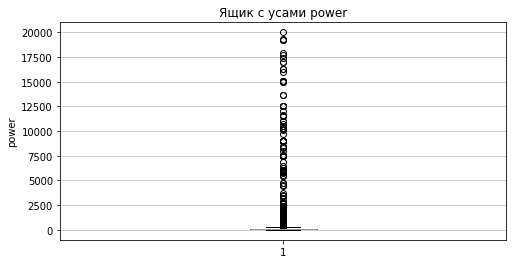

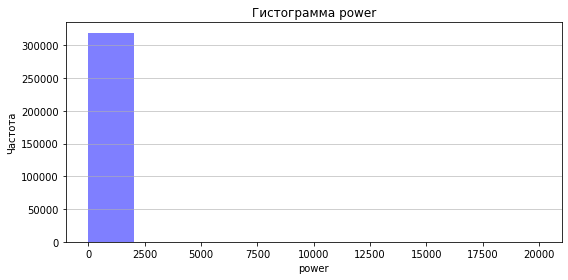

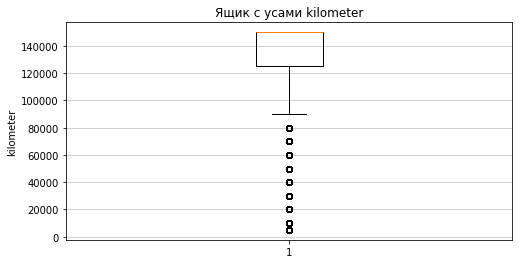

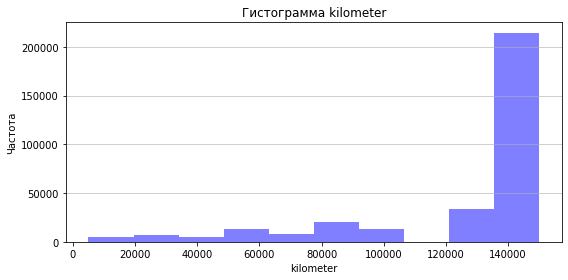

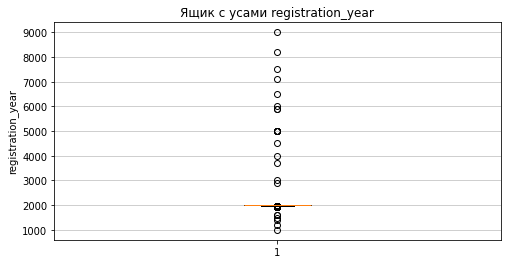

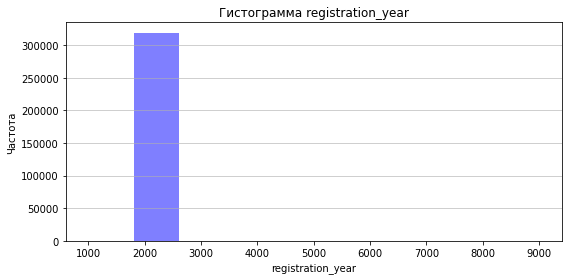

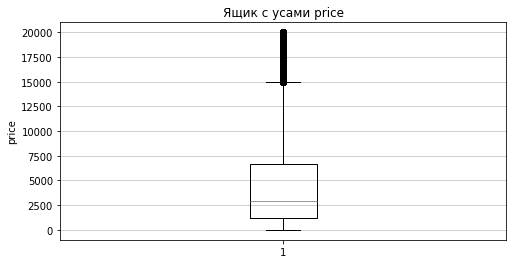

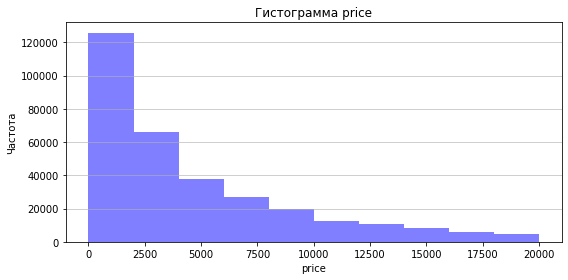

In [25]:
# визуализирую количественные признаки 
plot_numeric_features(data)

Удалю данные о мощности дигателя свыше 2500 л.с. и менее 15 л.с.

In [26]:
data=data.query('power > 15 & power < 2500')

В столбце registration_year удалю нереалистьчные данные

In [27]:
data = data.query('registration_year > 1900 & registration_year < 2016 & date_created < "2016-05-01 00:00:00"')

Удаляю строки для которых не указана цена

In [28]:
data=data.query('price > 0')

In [29]:
display(data.describe())

,power,kilometer,registration_year,price
count,275585.000000,275585.000000,275585.000000,275585.000000
mean,122.287436,128225.211822,2002.686616,4971.994484
std,63.412421,36561.527617,6.139972,4639.828129
min,16.000000,5000.000000,1910.000000,1.000000
25%,80.000000,125000.000000,1999.000000,1400.000000
50%,115.000000,150000.000000,2003.000000,3300.000000
75%,150.000000,150000.000000,2007.000000,7200.000000
max,2461.000000,150000.000000,2015.000000,20000.000000


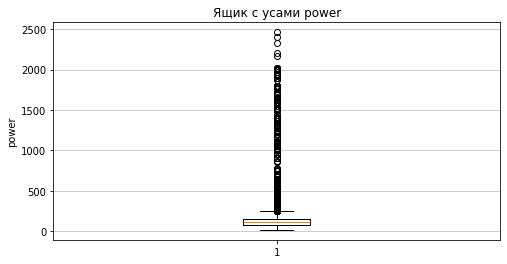

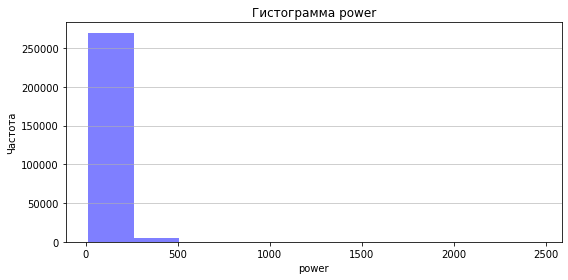

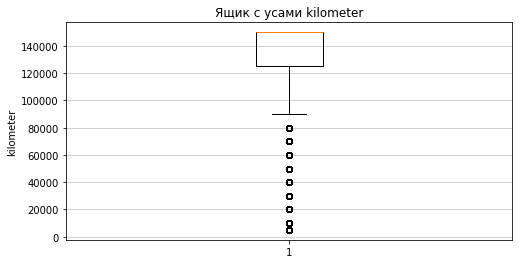

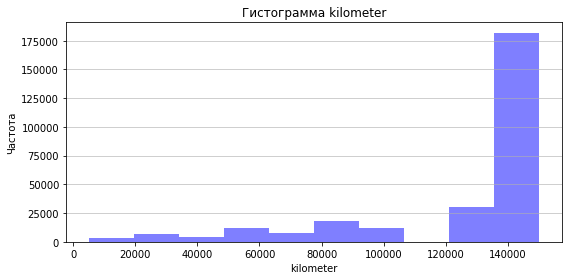

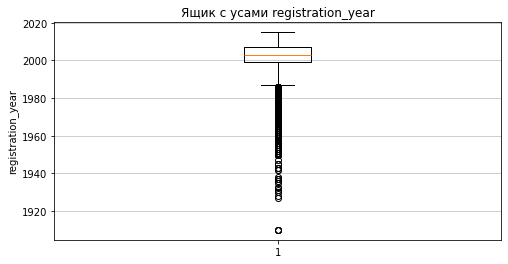

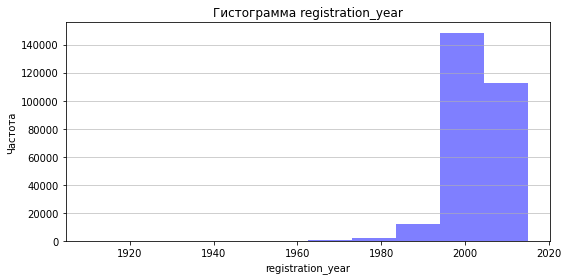

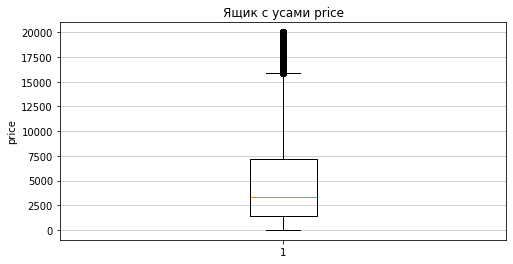

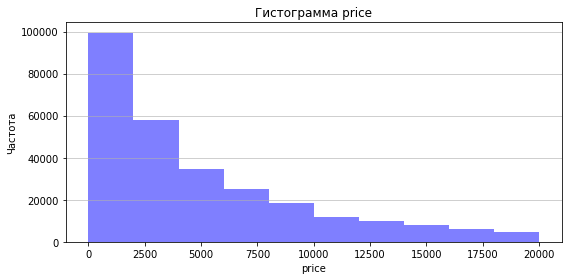

In [30]:
plot_numeric_features(data)

В основном на рынке представлены автомобили с мощностью двигателя до 150 л.с. Половина с максимальным пробегом (150000 км). Большинство зарегистрированы после 1999 года. Большинство машин продаются по цене до 8000 евро, но встречаются и до 20000 евро

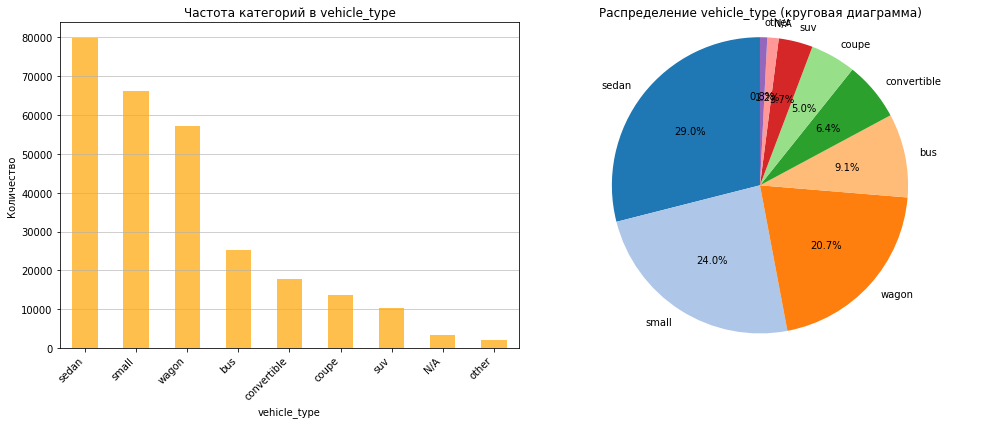

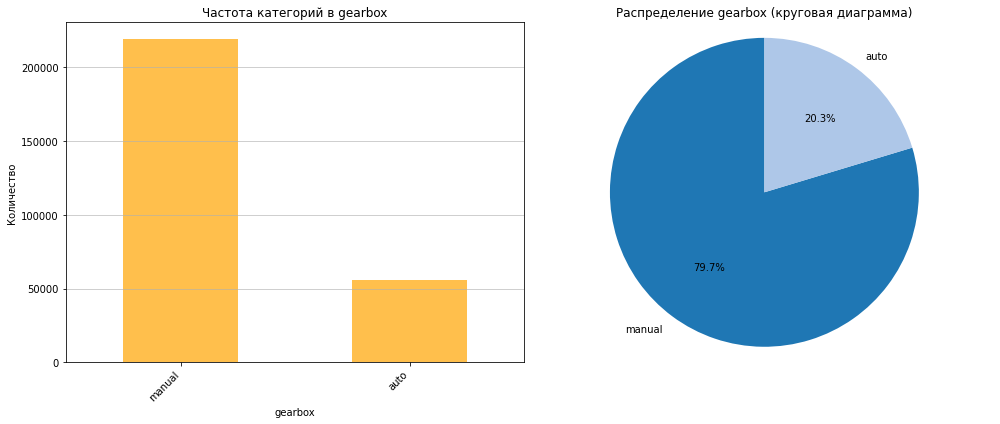

<Figure size 1008x432 with 0 Axes>

<Figure size 1008x432 with 0 Axes>

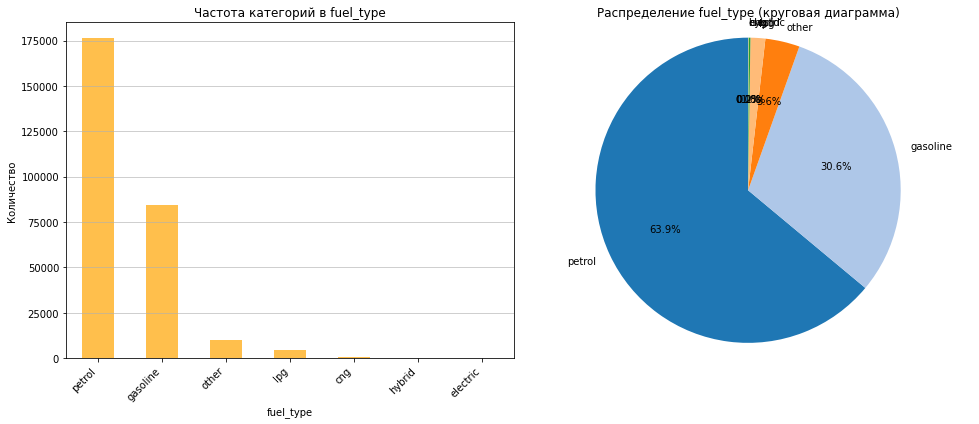

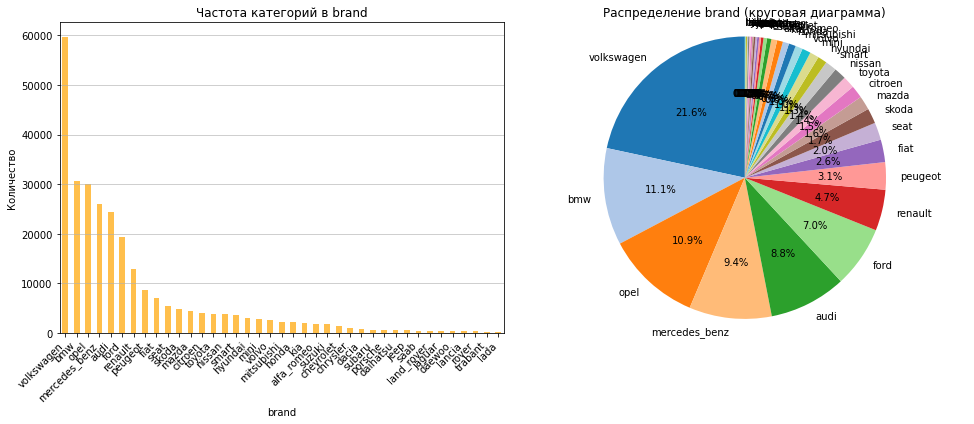

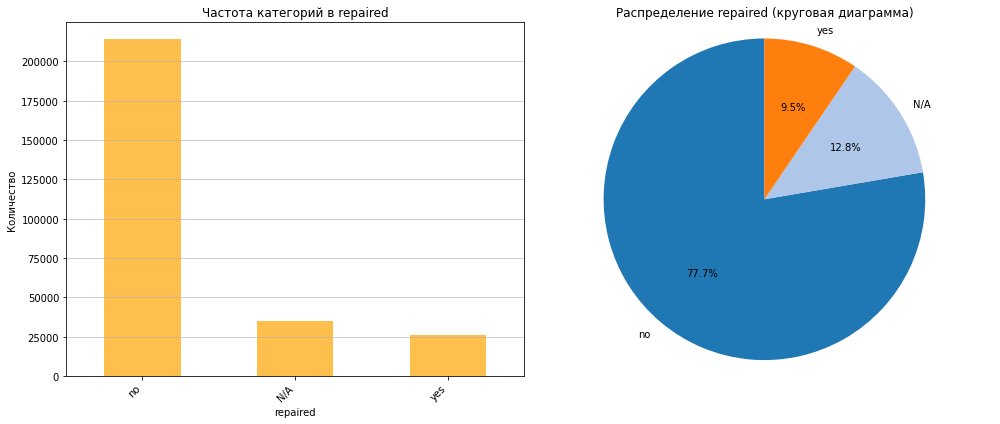

<Figure size 1008x432 with 0 Axes>

<Figure size 1008x432 with 0 Axes>

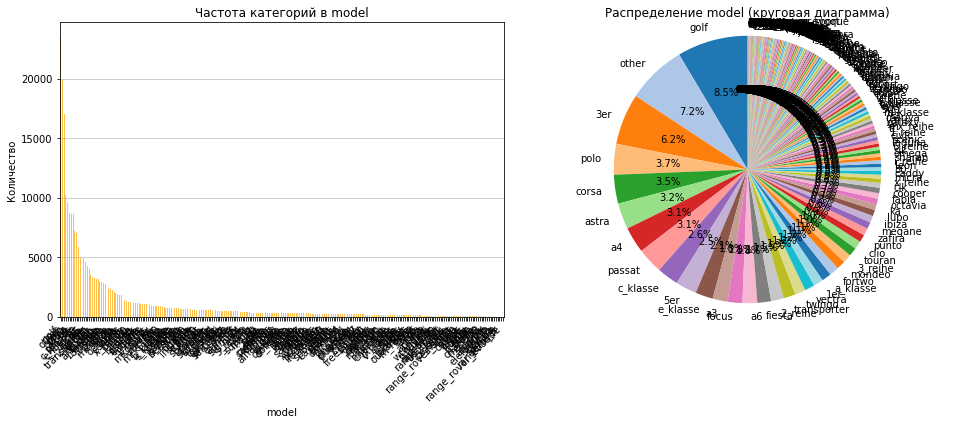

<Figure size 1008x432 with 0 Axes>

In [31]:
plot_categorical_features(data)

Половина всех автомобилей имеют кузова типа sedan и small.80% с автоматической коробкой передач. Более половины (63%) бензиновые, почти треть (29,9 %) газовые. Самая популярная марка volkswagen (21,9%). Три чеверти машин не были в ремонте

**Корреляционный анализ**

In [32]:
interval_columns = ['power', 'kilometer', 'registration_year', 'price']

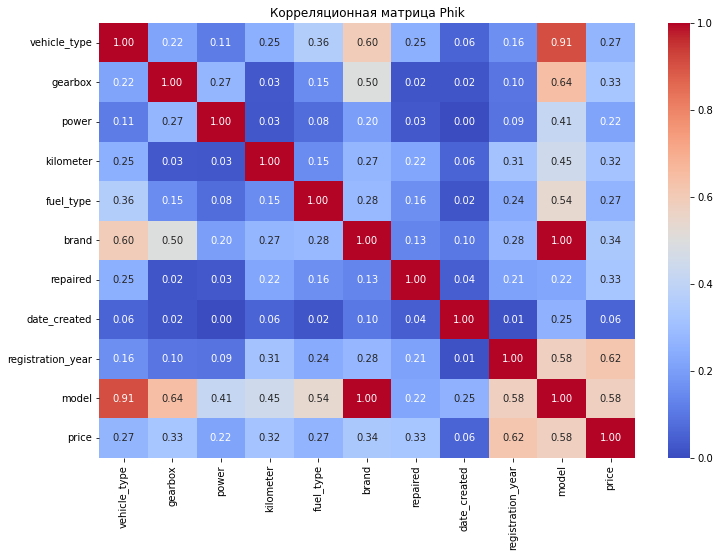

In [33]:
# вычисление матрицы корреляции с методом Phik
phik_matrix_result = data.phik_matrix(interval_cols=interval_columns)

# визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix_result, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 10})
plt.title('Корреляционная матрица Phik')
plt.show()

Нецелевые признаки vehicle_type и brand сильно кореллируют с нецелевым признаком model. Сильная корреляция между признаками может привести к мультиколлинеарности, что может негативно повлиять на интерпретацию итогов модели и её производительность. Предлагаю не учитывать столбец model при посторении модели

Финальный датасет будет выглядеть так:

In [34]:
data_final = data[['vehicle_type', 
                         'gearbox', 
                         'power',
                         'kilometer',
                         'fuel_type',
                         'brand',
                         'repaired',
                         'registration_year',
                         'price']]
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 275585 entries, 2 to 354368
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   vehicle_type       275585 non-null  object
 1   gearbox            275585 non-null  object
 2   power              275585 non-null  int64 
 3   kilometer          275585 non-null  int64 
 4   fuel_type          275585 non-null  object
 5   brand              275585 non-null  object
 6   repaired           275585 non-null  object
 7   registration_year  275585 non-null  int64 
 8   price              275585 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 21.0+ MB


In [35]:
display(data_final.tail())

,vehicle_type,gearbox,power,kilometer,fuel_type,brand,repaired,registration_year,price
354359,sedan,manual,140,150000,gasoline,volkswagen,no,2010,7900
354362,sedan,manual,225,150000,petrol,seat,yes,2004,3200
354366,convertible,auto,101,125000,petrol,smart,no,2000,1199
354367,bus,manual,102,150000,gasoline,volkswagen,no,1996,9200
354368,wagon,manual,100,150000,gasoline,volkswagen,N/A,2002,3400


In [36]:
# сбрасываю индексы
data_final=data_final.reset_index(drop=True)
display(data_final.tail())

,vehicle_type,gearbox,power,kilometer,fuel_type,brand,repaired,registration_year,price
275580,sedan,manual,140,150000,gasoline,volkswagen,no,2010,7900
275581,sedan,manual,225,150000,petrol,seat,yes,2004,3200
275582,convertible,auto,101,125000,petrol,smart,no,2000,1199
275583,bus,manual,102,150000,gasoline,volkswagen,no,1996,9200
275584,wagon,manual,100,150000,gasoline,volkswagen,N/A,2002,3400


**Вывод:**
- В основном на рынке представлены автомобили с мощностью двигателя до 150 л.с. Половина с максимальным пробегом (150000 км). Большинство зарегистрированы после 1999 года. Большинство машин продаются по цене до 8000 евро, но встречаются и до 20000 евро;
- Половина всех автомобилей имеют кузова типа sedan и small.80% с автоматической коробкой передач. Более половины (63%) бензиновые, почти треть (29,9 %) газовые. Самая популярная марка volkswagen (21,9%). Три чеверти машин не были в ремонте;
- Для дальнейшей работы был создан новый датафрейм data_final, в который вошли признаки: 'vehicle_type', 'gearbox',      'power', 'kilometer', 'fuel_type', 'brand', 'repaired', 'registration_year', 'price'. 

## Обучение моделей

Для обучения модели выберу следующие регрессоры:

- LinearRegression
- DecisionTreeRegressor
- CatBoostRegressor
- LGBMRegressor

В качестве метрики для оценки всех моделей будет использоваться среднеквадратичная ошибка (MSE), которая в итоговой таблице будет преобразована в корень из среднеквадратичной ошибки (RMSE). Для проверки качества моделей мы применим кросс-валидацию.


### Подготовка данных

Разделяю данные на основную выборку и целевые признаки

In [37]:
X = data_final.drop(['price'],axis=1)
y = data_final['price']

Разделяю данные на обучающую и тестовые выборки

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Кодирую категориальные переменные

In [39]:
cat_col=['vehicle_type', 'gearbox', 'fuel_type', 'brand', 'repaired']

In [40]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col])
X_test_ohe = encoder.transform(X_test[cat_col])
encoder_col_names = encoder.get_feature_names_out(cat_col)

In [41]:
# создание DataFrame для OHE
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=encoder_col_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=encoder_col_names, index=X_test.index)

Масштабирую числовые столбцы

In [42]:
num_col = ['power', 'kilometer', 'registration_year']

In [43]:
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_col])
X_test_num_scaled = scaler.transform(X_test[num_col])

Объединяю закодированные и мастабированные признаки

In [44]:
X_train_final = pd.concat([X_train_ohe_df, pd.DataFrame(X_train_num_scaled, columns=num_col, index=X_train.index)], axis=1)
X_test_final = pd.concat([X_test_ohe_df, pd.DataFrame(X_test_num_scaled, columns=num_col, index=X_test.index)], axis=1)

In [45]:
print(y_train.dtypes)

int64


**Вывод**

Текстовые признаки трансформированы в цифровой формат, числовые признаки масштабированы, выборки разделены на тренировочную и тестовую для проверки качества предсказания моделей. 

### Обучение моделей

In [46]:
def illustration_target(test, predict):
    # Вычисление метрик ошибок
    rmse = mean_squared_error(test, predict) ** 0.5
    mae = mean_absolute_error(test, predict)

    # Создание первой фигуры: гистограмма предсказанных и истинных значений
    plt.figure(figsize=(8, 5))
    pd.Series(predict).hist(bins=20, alpha=0.5, label='Предсказанные значения')
    pd.Series(test).hist(bins=20, alpha=0.5, label='Истинные значения')
    plt.legend()
    plt.title('График распределения предсказанных и истинных значений', y=1.05)
    plt.xlabel('Значения')
    plt.ylabel('Количество')
    plt.grid(True)
    plt.show()

    # Создание второй фигуры: график предсказанных значений против истинных
    plt.figure(figsize=(8, 8))
    plt.plot(predict, test, 'o', alpha=0.5)
    plt.xlim(-5000, 25000)
    plt.ylim(-5000, 25000)
    plt.plot([-10000, 25000], [-10000, 25000], '--y', linewidth=2)  # Линия идеального прогноза
    plt.title('График отношений предсказанных значений к истинным', y=1.05)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Истинные значения')
    plt.grid(True)
    plt.show()

In [47]:
def train_model(model, X, y, results_df, param_grid=None):
    start = time.time()

    if param_grid:  # Если есть сетка гиперпараметров
        halving_grid_cv = HalvingGridSearchCV(
            model, 
            param_grid, 
            factor=2,  # Уменьшает количество моделей вдвое на каждом этапе
            cv=5, 
            n_jobs=-1,
            scoring='neg_root_mean_squared_error', 
            return_train_score=True
        )
        halving_grid_cv.fit(X, y)
        best_model = halving_grid_cv.best_estimator_
        training_time = halving_grid_cv.cv_results_['mean_fit_time'][halving_grid_cv.best_index_]
        mean_score_time = halving_grid_cv.cv_results_['mean_score_time'][halving_grid_cv.best_index_]
        cross_val_rmse = -cross_val_score(best_model, X, y, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1).mean()
    else:  # Если гиперпараметры не подбираются
        cv_results = cross_validate(model, X, y, cv=5,
                                    scoring='neg_root_mean_squared_error', return_train_score=False,
                                    n_jobs=-1)
        training_time = np.mean(cv_results['fit_time'])
        mean_score_time = np.mean(cv_results['score_time'])
        model.fit(X, y)
        best_model = model
        cross_val_rmse = -np.mean(cv_results['test_score'])

    # Обучаем модель для предсказаний
    predictions = best_model.predict(X)
    mae_train = mean_absolute_error(y, predictions)
    rmse_train = np.sqrt(mean_squared_error(y, predictions))

    # Визуализация результатов (функция illustration_target должна быть реализована отдельно)
    illustration_target(y, predictions)

    result_row = {
        'Model': best_model.__class__.__name__,
        'Training Time': training_time,
        'Mean Score Time': mean_score_time,
        'MAE': mae_train,
        'RMSE': rmse_train,
        'Cross-Validation RMSE': cross_val_rmse
    }

    results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)

    print('Гиперпараметры модели:\n', best_model.get_params())
    print('MAE модели равен:', mae_train)
    print('RMSE модели равен:', rmse_train)

    return training_time, mae_train, rmse_train, best_model, cross_val_rmse, results_df


In [48]:
results_df = pd.DataFrame(columns=['Model', 'Training Time', 'Mean Score Time', 'MAE', 'RMSE', 'Cross-Validation RMSE'])

**LinearRegression**

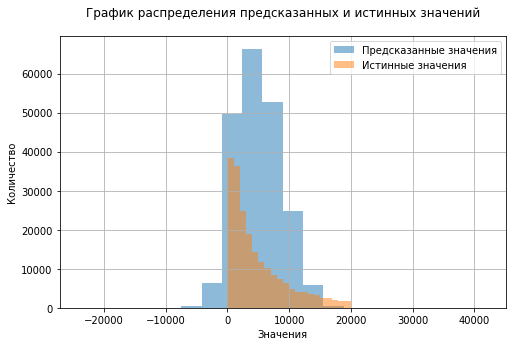

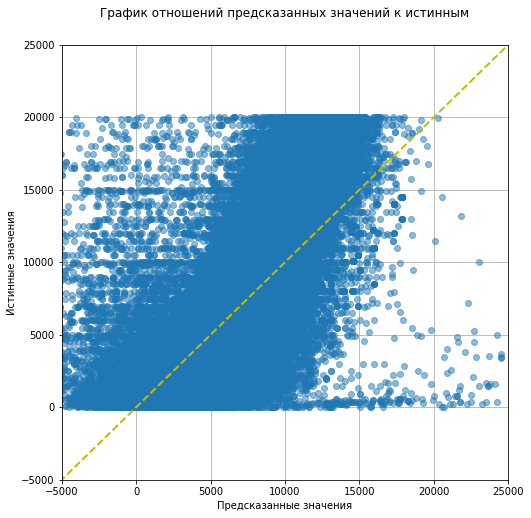

Гиперпараметры модели:
 {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
MAE модели равен: 1931.4506039608013
RMSE модели равен: 2794.7582974571874


In [49]:
linear_model = LinearRegression()
linear_param_grid = { }  # У LinearRegression нет гиперпараметров для подбора.
#training_time_lr, mae_train_lr, rmse_train_lr, best_model_lr, cross_val_mae_lr, results_df = train_model(linear_model, X_train_final, y_train, results_df, param_grid=linear_param_grid)
training_time_lr, mae_train_lr, rmse_train_lr, best_model_lr, cross_val_rmse_lr, results_df = train_model(linear_model, X_train_final, y_train, results_df, param_grid=linear_param_grid)

**DecisionTreeRegressor**

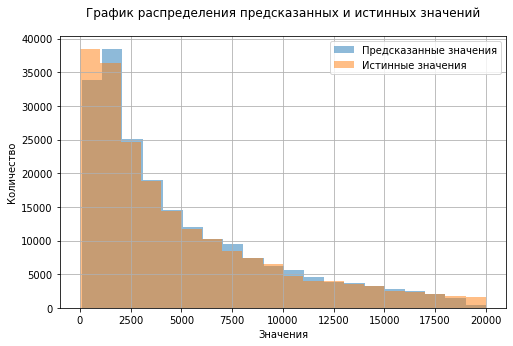

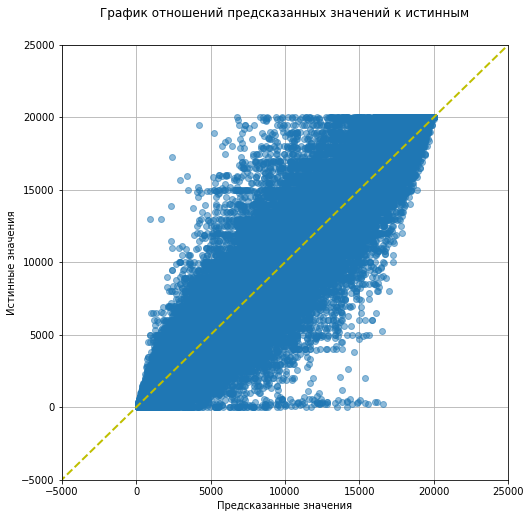

Гиперпараметры модели:
 {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
MAE модели равен: 842.3389838599506
RMSE модели равен: 1335.556503873604


In [50]:
decision_tree_model = DecisionTreeRegressor()
decision_tree_param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
training_time_dt, mae_train_dt, rmse_train_dt, best_model_dt, cross_val_rmse_dt, results_df = train_model(decision_tree_model, X_train_final, y_train, results_df, param_grid=decision_tree_param_grid)

**CatBoostRegressor**

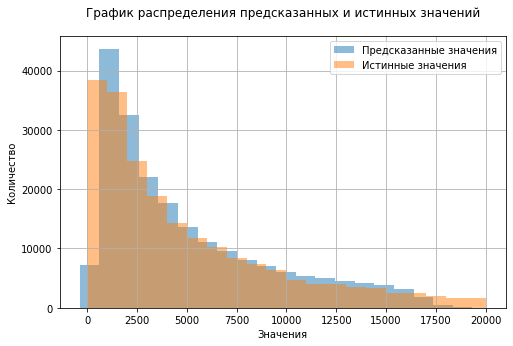

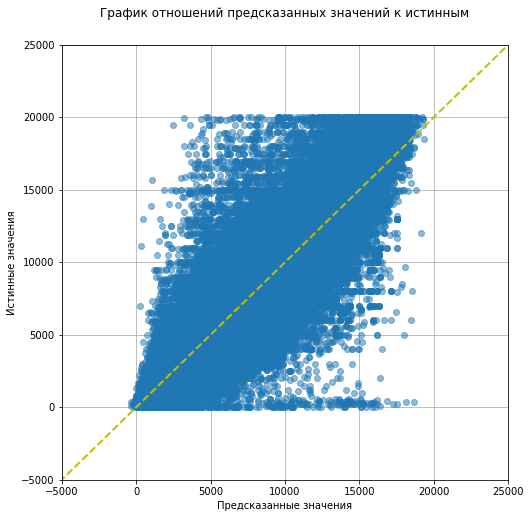

Гиперпараметры модели:
 {'loss_function': 'RMSE', 'silent': True, 'depth': 8, 'iterations': 200, 'l2_leaf_reg': 4, 'learning_rate': 0.05}
MAE модели равен: 1100.9740534470282
RMSE модели равен: 1704.135702398485


In [51]:
catboost_model = CatBoostRegressor(silent=True)
catboost_param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 200],
    'l2_leaf_reg': [4, 5]
}
training_time_cb, mae_train_cb, rmse_train_cb, best_model_cb, cross_val_rmse_cb, results_df = train_model(catboost_model, X_train_final, y_train, results_df, param_grid=catboost_param_grid)

**LightGBM**

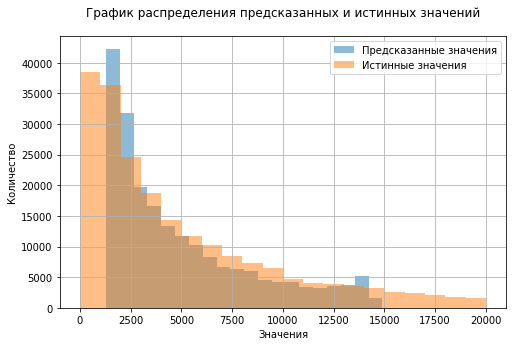

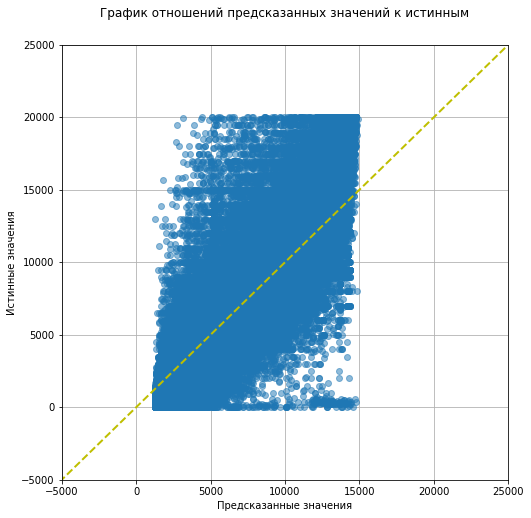

Гиперпараметры модели:
 {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 40, 'n_jobs': -1, 'num_leaves': 50, 'objective': None, 'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
MAE модели равен: 1379.3548565389876
RMSE модели равен: 1987.6865796107375


In [52]:
lgbm_model = LGBMRegressor()
lgbm_param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [-1, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [20, 40]
}
training_time_lgbm, mae_train_lgbm, rmse_train_lgbm, best_model_lgbm, cross_val_rmse_lgbm, results_df = train_model(lgbm_model, X_train_final, y_train, results_df, param_grid=lgbm_param_grid)

**Вывод**

Для обучения модели были выбраны следующие регрессоры:

- LinearRegression
- DecisionTreeRegressor	
- CatBoostRegressor
- LGBMRegressor


## Анализ моделей

In [53]:
display(results_df)

,Model,Training Time,Mean Score Time,MAE,RMSE,Cross-Validation RMSE
0,LinearRegression,4.838678,0.120743,1931.450604,2794.758297,2797.321268
1,DecisionTreeRegressor,1.313181,0.020812,842.338984,1335.556504,1753.039372
2,CatBoostRegressor,5.868696,0.018313,1100.974053,1704.135702,1724.925491
3,LGBMRegressor,2.415136,0.201088,1379.354857,1987.686580,1996.934000


Если ориентироваться на качество предсказания по кросс-валидационной метрике RMSE и времени предсказания, то лучшей моделью следует считать CatBoostRegressor.

MAE = 1112.3283370283866
RMSE = 1727.9453208043883


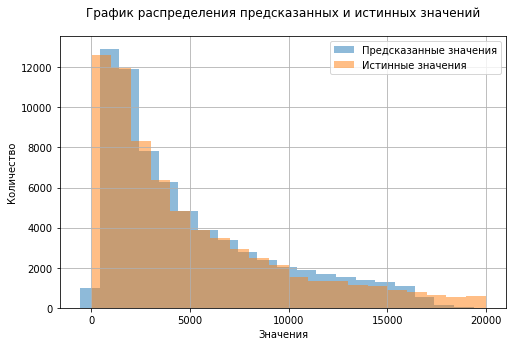

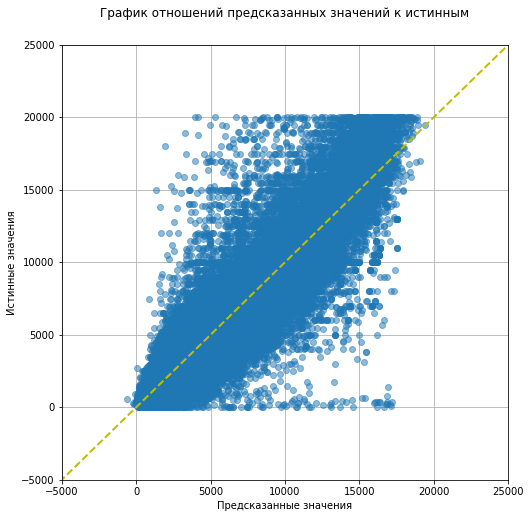

In [54]:
# Предсказание на тестовых данных
predictions = best_model_cb.predict(X_test_final)
        
# Расчет метрик
print(f'MAE = {mean_absolute_error(y_test, predictions)}')
print(f'RMSE = {np.sqrt(np.mean((y_test - predictions) ** 2))}') 

# Визуализация
illustration_target(y_test, predictions)

**Вывод**

Если ориентироваться на качество и скорость предсказания, то лучшей моделью следует считать CatBoostRegressor с гиперпараметрами {'loss_function': 'RMSE', 'silent': True, 'depth': 8, 'iterations': 200, 'l2_leaf_reg': 4, 'learning_rate': 0.05}. 
На тестовой выборке модель показывает хорошие метрики (MAE = 1112.3283370283866, RMSE = 1727.9453208043883)

## Общий вывод

В ходе данного исследования было необходимо построить модель машинного обучения, которая поможет определить рыночную стоимость автомобиля.

Работа состояла из нескольких этапов:
1. Подготовка данных: 
-  Названия столбцов приведены к стандартоному виду;
-  Столбцы с датой приведены к формату datetime64;
- В столбцах vehicle_type и repaired пропуски заменены на N/A. Строки с пропусками в gearbox и model удалены. Пропуски в fuel_type заменены на 'other';
- Удалены явные дубликаты;
- Для дальнейшей работы был создан новый датафрейм data_final, в который вошли признаки: 'vehicle_type', 'gearbox',      'power', 'kilometer', 'fuel_type', 'brand', 'repaired', 'registration_year', 'price'. 

2. Обучение моделей
- Текстовые признаки трансформированы в цифровой формат, числовые признаки масштабированы, выборки разделены на тренировочную и тестовую для проверки качества предсказания моделей;
- Для обучения модели выбраны следующие регрессоры:

- - LinearRegression
- - DecisionTreeRegressor
- - CatBoostRegressor
- - LGBMRegressor

3. Анализ моделей:
- По качеству предсказания на метриках MAE и RMSE и распределению значений на графиках лучше всех себя показала модель DecisionTreeRegressor с гиперпараметрами {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'} 

## Чек-лист проверки

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнена загрузка и подготовка данных
- [x]  Выполнено обучение моделей
- [x]  Есть анализ скорости работы и качества моделей

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**

Елена, спасибо за твой проект! У тебя хорошая работа! В тебе виден будущий профессионал своего дела :) Однако есть еще моменты, которые требуют твоего внимания.
    
Кратко пройдусь по впечатлениям. 

**Отмечу отдельные положительные моменты проекта🙂**:
 
* Прекрасное владение инструментами обработки данных!
* Дополнение своими идеями - очень круто!
* Умелое проведение машинного обучения!
* Все этапы работы проделаны очень осмысленно! Каждый шаг снабжен пояснениями и выводами!
* Работа имеет четкую структуру и выполнена аккуратно, проверять - одно удовольствие!

    
**На что стоит обратить внимание🤓**:
    
* Пересмотреть фильтрацию по году регистрации.
* Как минимум для одной модели необходимо произвести подбор гиперпараметров.
* Сравнение моделей производить на основе (кросс-) валидационных показателей.


**Желаю удачи и жду твой проект на повторное ревью!**😉
    
<img src="https://99px.ru/sstorage/86/2015/12/image_86271215043043632690.gif" />